Implement K-Nearest Neighbours’ algorithm on Social network ad dataset. Compute 
confusion matrix, accuracy, error rate, precision and recall on the given dataset. 
Dataset link:https://www.kaggle.com/datasets/rakeshrau/social-network-ads 

## K-Nearest Neighbor(KNN) Algorithm

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm generally used for classification but can also be used for regression tasks. It works by finding the "k" closest data points (neighbors) to a given input and makesa predictions based on the majority class (for classification) or the average value (for regression). Since KNN makes no assumptions about the underlying data distribution it makes it a non-parametric and instance-based learning method.

#### How KNN Algorithm Works (Step-by-Step in Simple Words)

Step 1: Choose K
Pick how many neighbors to look at. For example, K = 5 means “check the 5 closest people.”

Step 2: Measure Distance
Use Euclidean or other distance to calculate how far each person in the dataset is from the new one.

`Euclidean Distance` (like a straight line)
It’s like using a ruler to measure the shortest path between two points.

📌 Example:
If you're at point A and want to go to point B, and you can walk diagonally, this is the shortest path.

Step 3: Find Nearest Neighbors
Sort all distances and select the K smallest ones. These are the closest people (your neighbors).

Step 4: Make Prediction
👉 For Classification:
Check the labels (like "yes" or "no") of the K neighbors

Vote which label appears the most

That becomes the prediction

`Example :`
If among 5 neighbors:

3 said “Yes”

2 said “No”
🎯 Predict = Yes

<div style="text-align: center;">
  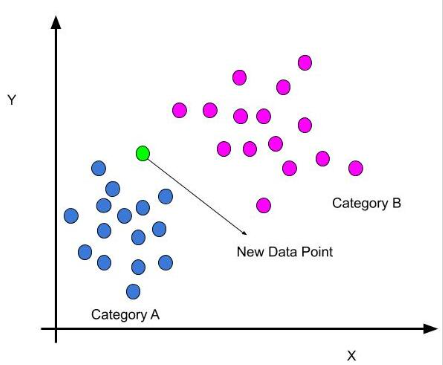
</div>

## About Dataset

This dataset is about users on a social network and whether they bought a product after seeing an ad.

| Column Name       | Description                                      |
|-------------------|-------------------------------------------------|
| **User ID**       | Unique identifier for each user (not used for prediction) |
| **Gender**        | Male or Female                                  |
| **Age**           | Age of the user (years)                         |
| **EstimatedSalary**| Estimated yearly salary of the user (in dollars) |
| **Purchased**     | Target variable:  

  - 1 means user **bought** the product  
  - 0 means user **did not buy** the product 


In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.shape

(400, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
395    False
396    False
397    False
398    False
399    False
Length: 400, dtype: bool

## Building a model

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [8]:
x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [9]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [10]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [11]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [13]:
y_pred = knn.predict(x_test)

In [14]:
y_pred

array([1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

In [15]:
acc = accuracy_score(y_test, y_pred)
acc

0.825

In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[46,  6],
       [ 8, 20]], dtype=int64)

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

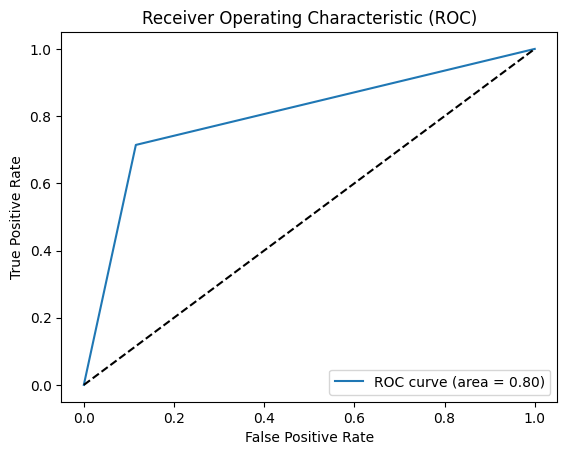

In [18]:

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

`ROC curve` shows how well your model can distinguish between classes at different threshold settings. It plots True Positive Rate (sensitivity) vs. False Positive Rate.

`AUC (Area Under the Curve)` is a single number summarizing the ROC curve — it tells you how good your model is overall at ranking positives higher than negatives.

In [19]:
# Compute error rate
error_rate = 1 - acc
print(f"Error Rate: {error_rate:.2f}")

Error Rate: 0.18


In [21]:
# Compute precision and recall
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")

Precision: 0.77


In [23]:
recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.2f}")

Recall: 0.71


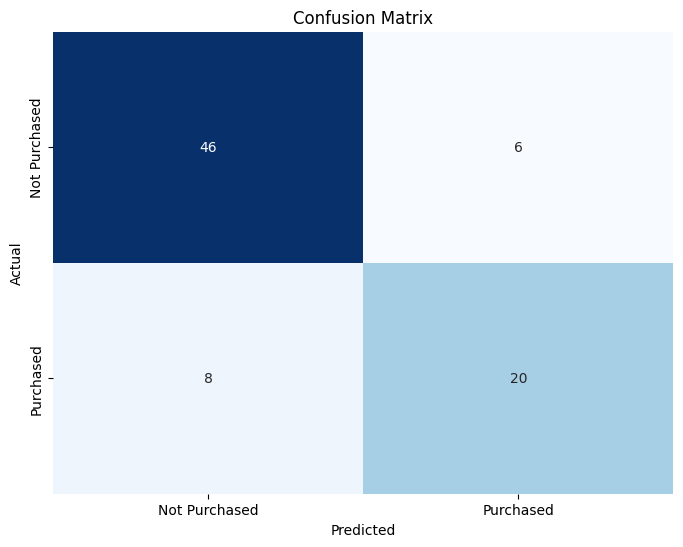

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

---

## Conclusion

This practical demonstrated the application of the **K-Nearest Neighbors (KNN)** algorithm on the **Social Network Ads dataset** for predicting user purchase behavior.

Based on the model's performance on the test set:

* **Accuracy**: The model achieved an accuracy of **0.825**, meaning it correctly predicted whether a user would purchase the product or not in **82.5%** of cases.
* **Error Rate**: The error rate is **0.18**, indicating the proportion of incorrect predictions.
* **Precision**: The precision is **0.77**. This means that when the model predicted a user would purchase, it was correct **77%** of the time. High precision indicates a low rate of False Positives.
* **Recall**: The recall is **0.71**. This means the model correctly identified **71%** of all users who actually purchased the product. High recall indicates a low rate of False Negatives.

The **Confusion Matrix** provides a more detailed breakdown of the model's performance:

* **True Positives (TP)**: **46** - The number of users who actually purchased and were correctly predicted as purchased.
* **True Negatives (TN)**: **20** - The number of users who did not purchase and were correctly predicted as not purchased.
* **False Positives (FP)**: **6** - The number of users who did not purchase but were incorrectly predicted as purchased (Type I error).
* **False Negatives (FN)**: **8** - The number of users who actually purchased but were incorrectly predicted as not purchased (Type II error).

In this case, the model has a higher number of True Positives and True Negatives compared to False Positives and False Negatives, which is desirable. The balance between precision and recall depends on the specific goals of the application.